# Algoritmos de Clusterização

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score,
                             adjusted_rand_score)

In [2]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Conjunto de dados

Usaremos 400 objetos bidimensionais gerados a partir de 4 distribuições gaussianas (`make_blobs`). O vetor `y` contém o grupo de origem de cada objeto. Em um problema real de agrupamento, esses rótulos **não existem**; aqui, eles serão usados apenas no final da Seção 4, para comparar a validação interna com a externa.

> **Preparação dos dados.** O $k$-means usa a distância euclidiana; por isso, atributos com escalas diferentes devem ser normalizados (por exemplo, com `StandardScaler`). Neste exemplo, os dois atributos já estão na mesma escala, e a normalização não é necessária.

In [3]:
X, y = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1,
    random_state=42,
)

print(f"Dimensão de X: {X.shape}  ({X.shape[0]} objetos, {X.shape[1]} atributos)")
print("Primeiros 5 objetos:")
print(X[:5])

Dimensão de X: (400, 2)  (400 objetos, 2 atributos)
Primeiros 5 objetos:
[[-10.11875711   9.0783171 ]
 [ -5.12894273   9.83618863]
 [ -9.08407082   7.05079935]
 [  5.61499857   1.8261123 ]
 [  5.21076935   3.10873532]]


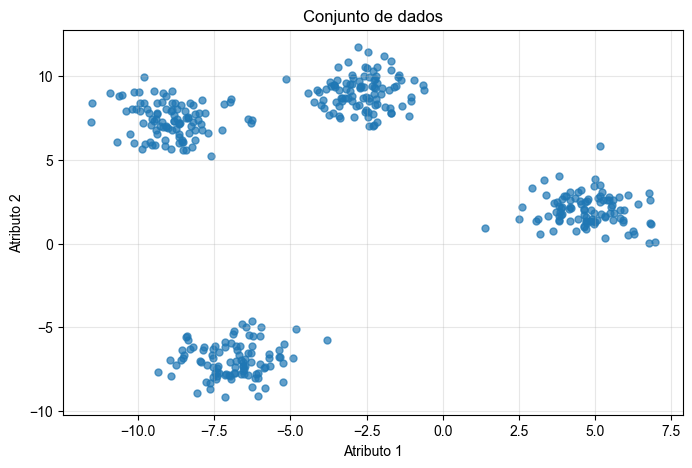

In [4]:
plt.scatter(X[:, 0], X[:, 1], s=25, alpha=0.7)
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.title("Conjunto de dados")
plt.grid(alpha=0.3)
plt.show()

## 2. $k$-means com a `scikit-learn`

Principais parâmetros da classe `KMeans`:

| Parâmetro | Significado |
|---|---|
| `n_clusters` | número de grupos $K$ |
| `init` | inicialização dos centróides (`"k-means++"`, padrão, ou `"random"`) |
| `n_init` | número de execuções com inicializações diferentes; mantém-se a de menor inércia |
| `max_iter` | número máximo de iterações por execução |
| `tol` | tolerância para o deslocamento dos centróides (critério de parada) |
| `random_state` | semente, para reprodutibilidade |

Após o ajuste, ficam disponíveis `labels_` (rótulos), `cluster_centers_` (centróides), `inertia_` (inércia) e `n_iter_` (iterações da melhor execução).

In [5]:
modelo_sk = KMeans(n_clusters=4, n_init=10, max_iter=100, tol=1e-3, random_state=42)
rotulos_sk = modelo_sk.fit_predict(X)

print(f"Inércia: {modelo_sk.inertia_:.4f}")
print(f"Iterações (melhor execução): {modelo_sk.n_iter_}")
print("\nCentróides:")
for i, c in enumerate(modelo_sk.cluster_centers_):
    print(f"  m_{i+1} = ({c[0]:+.4f}, {c[1]:+.4f})")

Inércia: 766.5183
Iterações (melhor execução): 2

Centróides:
  m_1 = (+4.7471, +2.0106)
  m_2 = (-2.6332, +9.0436)
  m_3 = (-6.8839, -6.9840)
  m_4 = (-8.9292, +7.3820)


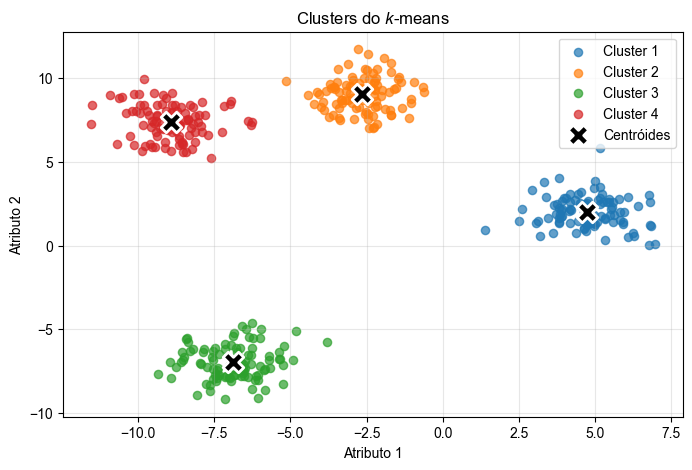

In [6]:
for c in range(4):
    mask = rotulos_sk == c
    plt.scatter(X[mask, 0], X[mask, 1], s=35, alpha=0.7, label=f"Cluster {c+1}")
plt.scatter(modelo_sk.cluster_centers_[:, 0], modelo_sk.cluster_centers_[:, 1],
            marker="X", s=220, c="black", edgecolors="white", linewidths=2,
            label="Centróides", zorder=5)
plt.title("Clusters do $k$-means")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.legend()
plt.grid(alpha=0.3)

## 3. Implementação manual

O $k$-means busca a partição $\{C_1, \dots, C_K\}$ e os centróides $\mathbf{m}_1, \dots, \mathbf{m}_K$ que minimizam a **inércia**

$$
J = \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \|\mathbf{x}_i - \mathbf{m}_k\|^2 .
$$

O algoritmo de Lloyd alterna dois passos até a convergência:

1. **Atribuição**: cada objeto vai para o grupo do centróide mais próximo, $c_i = \arg\min_k \|\mathbf{x}_i - \mathbf{m}_k\|^2$;
2. **Atualização**: cada centróide passa a ser a média dos objetos do seu grupo.

Nenhum dos dois passos aumenta $J$; por isso, o algoritmo sempre converge, mas para um **mínimo local** que depende da inicialização.

**Algumas Melhoras de Implementação:**

- **Inicialização $k$-means++** (além da aleatória): o primeiro centróide é sorteado uniformemente; cada novo centróide é sorteado com probabilidade proporcional a $D(\mathbf{x})^2$, o quadrado da distância de $\mathbf{x}$ ao centróide já escolhido mais próximo:
$$
P(\mathbf{x}) = \frac{D(\mathbf{x})^2}{\sum_{\mathbf{x}'} D(\mathbf{x}')^2}.
$$
- **Distâncias vetorizadas**: em vez de um laço sobre os grupos, todas as distâncias são calculadas de uma vez pela identidade
$$
\|\mathbf{x} - \mathbf{m}\|^2 = \|\mathbf{x}\|^2 - 2\,\mathbf{x}^{\mathsf{T}}\mathbf{m} + \|\mathbf{m}\|^2,
$$
que reduz o cálculo a um produto matricial $\mathbf{X}\mathbf{M}^{\mathsf{T}}$.

In [8]:
class myKMeans:
    """
    Implementação didática do k-means (algoritmo de Lloyd), com interface
    semelhante à da classe KMeans do scikit-learn.

    Ideia do algoritmo
    ------------------
    1. Escolher K centróides iniciais.
    2. Atribuição: cada objeto vai para o grupo do centróide mais próximo.
    3. Atualização: cada centróide passa a ser a média dos objetos do seu grupo.
    4. Repetir 2 e 3 até os centróides praticamente pararem de se mover.

    Parâmetros
    ----------
    n_clusters : int
        Número de grupos (K).
    init : {"k-means++", "random"}
        Método de inicialização dos centróides.
    n_init : int
        Número de execuções com inicializações diferentes; mantém-se a de menor inércia.
    max_iter : int
        Número máximo de iterações por execução.
    tol : float
        Tolerância de convergência: para quando o maior deslocamento de um
        centróide entre duas iterações é menor ou igual a tol.
    random_state : int ou None
        Semente do gerador de números aleatórios.

    Atributos (após o ajuste)
    -------------------------
    cluster_centers_ : ndarray, shape (n_clusters, n_features)
    labels_ : ndarray, shape (n_samples,)
    inertia_ : float
        Soma dos quadrados das distâncias de cada objeto ao centróide do seu grupo.
    n_iter_ : int
        Número de iterações da melhor execução.
    historico_inercia_ : list
        Inércia após cada passo de atribuição da melhor execução.

    Notação usada nos comentários
    -----------------------------
    n : número de objetos (linhas de X)
    d : número de atributos (colunas de X)
    K : número de grupos (n_clusters)
    """

    # ------------------------------------------------------------------
    # Construtor: apenas guarda os hiperparâmetros. Nenhum cálculo é feito
    # aqui; o aprendizado acontece em fit().
    # ------------------------------------------------------------------
    def __init__(self, n_clusters=8, init="k-means++", n_init=10, max_iter=300,
                 tol=1e-4, random_state=None):
        # Hiperparâmetros (definidos pelo usuário antes do ajuste)
        self.n_clusters = n_clusters
        self.init = init
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        # Resultados do ajuste. Por convenção (como na scikit-learn), atributos
        # aprendidos terminam com "_"
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = None
        self.historico_inercia_ = None

    # ------------------------------------------------------------------
    # Métodos auxiliares. O "_" no início do nome indica que são de uso
    # interno da classe: o usuário chama apenas fit, predict e fit_predict.
    # ------------------------------------------------------------------
    def _distancias_quadradas(self, X, centroides):
        """
        Calcula a distância euclidiana ao quadrado entre TODOS os objetos e
        TODOS os centróides, de uma só vez.

        Entradas: X com shape (n, d) e centroides com shape (K, d).
        Saída: matriz com shape (n, K), em que o elemento [i, j] vale
        ||x_i - m_j||^2 (objeto i, centróide j).

        Em vez de um laço, usa a identidade
            ||x - m||^2 = ||x||^2 - 2 x^T m + ||m||^2,
        que transforma o cálculo em um produto de matrizes (muito mais rápido).
        """
        # np.sum(X ** 2, axis=1): soma os quadrados de cada LINHA de X,
        # ou seja, ||x_i||^2 de cada objeto -> shape (n,).
        # [:, None] transforma esse vetor em uma COLUNA -> shape (n, 1).
        termo_x = np.sum(X ** 2, axis=1)[:, None]

        # X @ centroides.T: produto matricial (n, d) @ (d, K) -> (n, K).
        # O elemento [i, j] é o produto interno x_i^T m_j.
        termo_cruzado = X @ centroides.T

        # ||m_j||^2 de cada centróide, transformado em uma LINHA -> shape (1, K).
        termo_m = np.sum(centroides ** 2, axis=1)[None, :]

        # Broadcasting: o NumPy "estica" a coluna (n, 1) e a linha (1, K)
        # para (n, K) e soma elemento a elemento.
        d2 = termo_x - 2 * termo_cruzado + termo_m

        # Por erros de arredondamento, valores que deveriam ser 0 podem sair
        # ligeiramente negativos (ex.: -1e-15). Uma distância ao quadrado
        # nunca é negativa, então trocamos esses valores por 0.
        return np.maximum(d2, 0.0)

    def _init_centroids(self, X, rng):
        """
        Escolhe os K centróides iniciais. Retorna uma matriz (K, d).

        - "random": sorteia K objetos distintos do conjunto.
        - "k-means++": sorteia o 1º centróide ao acaso e os demais com
          probabilidade proporcional ao quadrado da distância ao centróide
          já escolhido mais próximo (pontos distantes têm mais chance).
        """
        n = len(X)  # número de objetos

        if self.init == "random":
            # Sorteia K índices entre 0 e n-1, sem repetição (replace=False),
            # para que dois centróides não comecem no mesmo objeto.
            idx = rng.choice(n, size=self.n_clusters, replace=False)
            return X[idx].copy()

        if self.init == "k-means++":
            # 1º centróide: um objeto sorteado uniformemente.
            # rng.integers(n) devolve um inteiro entre 0 e n-1.
            centroides = [X[rng.integers(n)]]

            # d2[i] = distância ao quadrado do objeto i ao centróide MAIS
            # PRÓXIMO entre os já escolhidos. No início, só existe um.
            d2 = np.sum((X - centroides[0]) ** 2, axis=1)  # shape (n,)

            # Escolhe os centróides 2, 3, ..., K
            for _ in range(1, self.n_clusters):
                # Probabilidade de cada objeto ser escolhido: d2 / soma(d2).
                novo = X[rng.choice(n, p=d2 / d2.sum())]
                centroides.append(novo)

                # Atualiza a distância ao centróide mais próximo: para cada
                # objeto, o menor valor entre a distância antiga e a distância
                # ao novo centróide
                d2 = np.minimum(d2, np.sum((X - novo) ** 2, axis=1))

            # Converte a lista de K vetores em uma matriz (K, d).
            return np.array(centroides)

        # Se init não for nenhuma das opções acima, avisa o usuário.
        raise ValueError('init deve ser "k-means++" ou "random".')

    def _assign(self, X, centroides):
        """
        PASSO DE ATRIBUIÇÃO: associa cada objeto ao centróide mais próximo.

        Retorna:
        - rotulos: vetor (n,) com o índice do grupo de cada objeto (0 a K-1);
        - a distância ao quadrado de cada objeto ao centróide do seu grupo, (n,).
        """
        # Matriz (n, K) com todas as distâncias objeto-centróide.
        d2 = self._distancias_quadradas(X, centroides)
        rotulos = np.argmin(d2, axis=1)
        return rotulos, d2[np.arange(len(X)), rotulos]

    def _update(self, X, rotulos, centroides, dist2):
        """
        PASSO DE ATUALIZAÇÃO: cada centróide passa a ser a média dos objetos
        do seu grupo. A média é o ponto que minimiza a soma dos quadrados das
        distâncias aos objetos do grupo.

        dist2 (distância de cada objeto ao seu centróide) só é usado no caso
        raro de um grupo ficar vazio.
        """
        # Trabalhamos com cópias para não modificar os arrays recebidos.
        novos = centroides.copy()
        dist2 = dist2.copy()

        for j in range(self.n_clusters):
            # Máscara booleana: vetor (n,) com True nos objetos do grupo j.
            mascara = rotulos == j

            if mascara.any():  # o grupo j tem pelo menos um objeto?
                novos[j] = X[mascara].mean(axis=0)
            else:
                # Grupo vazio: a média não existe (divisão por zero).
                # Solução: o centróide passa a ser o objeto mais distante do
                # seu centróide atual
                i = np.argmax(dist2)
                novos[j] = X[i]
                # Zera a distância desse objeto para que ele não seja escolhido
                # de novo, caso outro grupo também esteja vazio.
                dist2[i] = 0.0

        return novos

    def _run_once(self, X, rng):
        """
        Uma execução completa do k-means a partir de uma inicialização.

        Retorna: centróides finais, rótulos, inércia, número de iterações e o
        histórico da inércia.
        """
        # Passo 1: centróides iniciais e primeira atribuição.
        centroides = self._init_centroids(X, rng)
        rotulos, dist2 = self._assign(X, centroides)

        # Inércia = soma das distâncias ao quadrado de cada objeto ao centróide
        # do seu grupo.
        historico = [dist2.sum()]

        for it in range(1, self.max_iter + 1):
            # Passo de atualização: novos centróides = médias dos grupos.
            novos = self._update(X, rotulos, centroides, dist2)

            # Quanto cada centróide se moveu?
            deslocamento = np.max(np.linalg.norm(novos - centroides, axis=1))

            # Passo de atribuição com os novos centróides.
            centroides = novos
            rotulos, dist2 = self._assign(X, centroides)
            historico.append(dist2.sum())

            # Critério de parada: se nenhum centróide se moveu mais que tol,
            # o algoritmo convergiu.
            if deslocamento <= self.tol:
                break

        # dist2.sum() é a inércia final; "it" é o número de iterações feitas.
        return centroides, rotulos, dist2.sum(), it, historico

    # ------------------------------------------------------------------
    # Métodos públicos (os que o usuário chama)
    # ------------------------------------------------------------------
    def fit(self, X):
        """
        Ajusta o modelo aos dados X, shape (n, d).

        Como o resultado depende da inicialização (o k-means converge para um
        mínimo LOCAL), o algoritmo é executado n_init vezes e mantém-se a
        execução de menor inércia.
        """
        # Garante que X seja um array NumPy de números reais (aceita listas,
        # DataFrames etc.).
        X = np.asarray(X, dtype=float)

        if self.n_clusters > len(X):
            raise ValueError("n_clusters não pode ser maior que o número de objetos.")

        # Gerador de números aleatórios. Com a mesma semente (random_state),
        # os sorteios se repetem e os resultados são reprodutíveis.
        rng = np.random.default_rng(self.random_state)

        # Começa com inércia "infinita": qualquer execução será melhor.
        self.inertia_ = np.inf

        for _ in range(self.n_init):
            centroides, rotulos, inercia, n_iter, historico = self._run_once(X, rng)

            # Se esta execução foi a melhor até agora, guarda seus resultados.
            if inercia < self.inertia_:
                self.cluster_centers_ = centroides
                self.labels_ = rotulos
                self.inertia_ = inercia
                self.n_iter_ = n_iter
                self.historico_inercia_ = historico

        return self

    def fit_predict(self, X):
        """Ajusta o modelo e retorna os rótulos dos objetos de X."""
        return self.fit(X).labels_

    def predict(self, X):
        """
        Atribui NOVOS objetos ao centróide mais próximo, usando os centróides
        aprendidos em fit(). Os centróides NÃO são alterados.
        """
        if self.cluster_centers_ is None:
            raise RuntimeError("Modelo não ajustado: chame fit() antes de predict().")

        # _assign retorna (rotulos, distancias); [0] pega só os rótulos.
        return self._assign(np.asarray(X, dtype=float), self.cluster_centers_)[0]

Ajustamos o modelo e comparamos com a `scikit-learn`.

In [9]:
modelo_my = myKMeans(n_clusters=4, n_init=10, random_state=42)
rotulos_my = modelo_my.fit_predict(X)

print(f"Inércia (myKMeans):     {modelo_my.inertia_:.4f}")
print(f"Inércia (scikit-learn): {modelo_sk.inertia_:.4f}")
print(f"Iterações (melhor execução): {modelo_my.n_iter_}")

print("\nCentróides (ordenados pelo atributo 1):")
for c in modelo_my.cluster_centers_[np.argsort(modelo_my.cluster_centers_[:, 0])]:
    print(f"  ({c[0]:+.4f}, {c[1]:+.4f})")

Inércia (myKMeans):     766.5183
Inércia (scikit-learn): 766.5183
Iterações (melhor execução): 2

Centróides (ordenados pelo atributo 1):
  (-8.9292, +7.3820)
  (-6.8839, -6.9840)
  (-2.6332, +9.0436)
  (+4.7471, +2.0106)


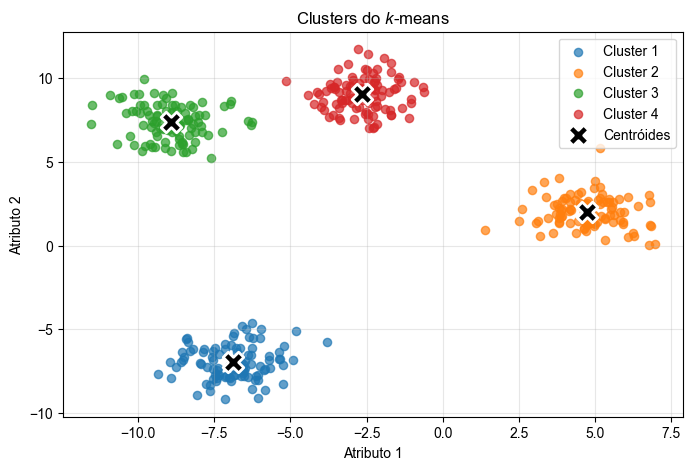

In [25]:
for c in range(4):
    mask = rotulos_my == c
    plt.scatter(X[mask, 0], X[mask, 1], s=35, alpha=0.7, label=f"Cluster {c+1}")
plt.scatter(modelo_my.cluster_centers_[:, 0], modelo_my.cluster_centers_[:, 1],
            marker="X", s=220, c="black", edgecolors="white", linewidths=2,
            label="Centróides", zorder=5)
plt.title("Clusters do $k$-means")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.legend()
plt.grid(alpha=0.3)

### 3.1 Convergência: evolução da inércia

O atributo `historico_inercia_` guarda a inércia após cada passo de atribuição. Como nenhum passo do algoritmo aumenta $J$, a sequência é **não crescente**. Para tornar a evolução visível, usamos a inicialização aleatória com uma única execução, que parte de uma configuração ruim.

Atribuição 0: J =   22375.36
Atribuição 1: J =   11982.71
Atribuição 2: J =   11330.98
Atribuição 3: J =    8886.25
Atribuição 4: J =     794.48
Atribuição 5: J =     766.52
Atribuição 6: J =     766.52


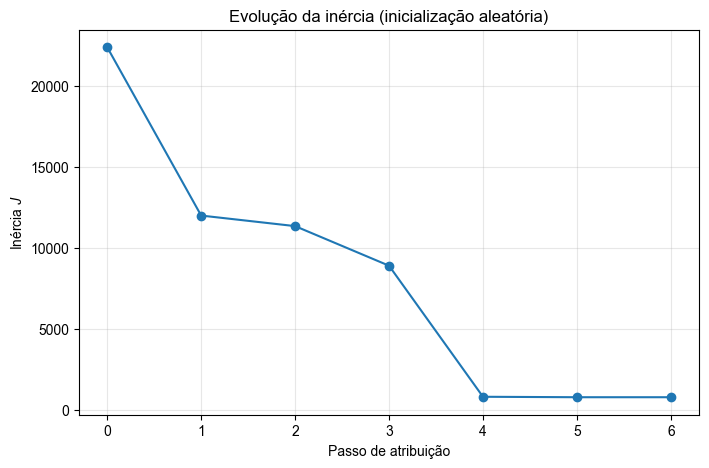

In [11]:
modelo_rand = myKMeans(n_clusters=4, init="random", n_init=1, random_state=1).fit(X)
historico = modelo_rand.historico_inercia_

for t, J in enumerate(historico):
    print(f"Atribuição {t}: J = {J:10.2f}")

plt.plot(range(len(historico)), historico, marker="o")
plt.xlabel("Passo de atribuição")
plt.ylabel("Inércia $J$")
plt.title("Evolução da inércia (inicialização aleatória)")
plt.grid(alpha=0.3)
plt.show()

### 3.2 Importância da inicialização

Executamos o algoritmo 100 vezes, com **uma única inicialização** por vez (`n_init=1`) e sementes diferentes, e contamos quantas execuções atingem a melhor inércia conhecida.

In [13]:
melhor_J = modelo_sk.inertia_
resultados = {}
for metodo in ["random", "k-means++"]:
    J = np.array([myKMeans(n_clusters=4, init=metodo, n_init=1, random_state=s).fit(X).inertia_
                  for s in range(100)])
    acertos = np.sum(np.isclose(J, melhor_J, rtol=1e-6))
    resultados[metodo] = J
    print(f"{metodo:>10}: {acertos}/100 execuções atingiram J = {melhor_J:.1f}; "
          f"pior J = {J.max():.1f}")

    random: 65/100 execuções atingiram J = 766.5; pior J = 12729.8
 k-means++: 86/100 execuções atingiram J = 766.5; pior J = 2833.9


A inicialização $k$-means++ reduz bastante a chance de ficar presa em um mínimo local ruim, mas não a elimina. Por isso, mesmo com $k$-means++, recomenda-se executar o algoritmo várias vezes (`n_init`) e manter a solução de menor inércia. A `scikit-learn` usa uma variante "gulosa" do $k$-means++, que testa vários candidatos a cada novo centróide e é ainda mais robusta.

## 4. Validação interna

Sem rótulos, como saber se um agrupamento é bom? Os critérios de validação se dividem em:

- **internos**: usam apenas os dados e a partição;
- **externos**: comparam a partição com rótulos de referência (raramente disponíveis);
- **relativos**: comparam partições obtidas com algoritmos ou parâmetros diferentes (por exemplo, diferentes valores de $K$), em geral usando índices internos.

Os índices internos combinam duas ideias:

- **coesão**: objetos do mesmo grupo devem estar próximos;
- **separação**: objetos de grupos diferentes devem estar distantes.

A seguir, implementamos manualmente os principais índices e conferimos os resultados com a `scikit-learn`.

### 4.1 Inércia e a decomposição $\text{SST} = \text{SSW} + \text{SSB}$

Sejam $\bar{\mathbf{x}}$ a média global, $\mathbf{m}_k$ o centróide e $n_k$ o número de objetos do grupo $k$:

$$
\text{SST} = \sum_{i=1}^{n} \|\mathbf{x}_i - \bar{\mathbf{x}}\|^2, \qquad
\text{SSW} = \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \|\mathbf{x}_i - \mathbf{m}_k\|^2, \qquad
\text{SSB} = \sum_{k=1}^{K} n_k \|\mathbf{m}_k - \bar{\mathbf{x}}\|^2 .
$$

- **SSW** (soma de quadrados intragrupos) é a **inércia**: mede a **coesão**.
- **SSB** (soma de quadrados entre grupos) mede a **separação**.
- Para qualquer particionamento rígido, $\text{SST} = \text{SSW} + \text{SSB}$. Como SST depende só dos dados, minimizar SSW equivale a maximizar SSB.

In [14]:
def somas_de_quadrados(X, rotulos):
    """Retorna (SST, SSW, SSB) de uma partição."""
    media = X.mean(axis=0)
    SST = np.sum((X - media) ** 2)
    SSW = SSB = 0.0
    for k in np.unique(rotulos):
        Xk = X[rotulos == k]
        mk = Xk.mean(axis=0)
        SSW += np.sum((Xk - mk) ** 2)
        SSB += len(Xk) * np.sum((mk - media) ** 2)
    return SST, SSW, SSB

SST, SSW, SSB = somas_de_quadrados(X, rotulos_my)
print(f"SST       = {SST:12.4f}")
print(f"SSW       = {SSW:12.4f}   (inertia_ = {modelo_my.inertia_:.4f})")
print(f"SSB       = {SSB:12.4f}")
print(f"SSW + SSB = {SSW + SSB:12.4f}")
print(f"\nFração da variabilidade explicada pela separação: SSB/SST = {SSB / SST:.2%}")

SST       =   27364.5626
SSW       =     766.5183   (inertia_ = 766.5183)
SSB       =   26598.0443
SSW + SSB =   27364.5626

Fração da variabilidade explicada pela separação: SSB/SST = 97.20%


A inércia, sozinha, tem duas limitações importantes:

1. mede apenas a coesão, não a separação;
2. **sempre diminui quando $K$ aumenta** (com $K = n$, cada objeto é o próprio centróide e $J = 0$).

Por isso, a inércia serve para comparar execuções com o **mesmo** $K$, mas não para escolher $K$ diretamente. Os índices a seguir combinam coesão e separação.

### 4.2 Coeficiente de silhueta

Para cada objeto $\mathbf{x}_i$, pertencente ao grupo $C_I$:

- $a(i)$: distância média de $\mathbf{x}_i$ aos **demais objetos do seu grupo** (coesão);
- $b(i)$: menor distância média de $\mathbf{x}_i$ aos objetos de **outro grupo**, o grupo "vizinho" (separação);

$$
a(i) = \frac{1}{|C_I| - 1} \sum_{\mathbf{x}_j \in C_I,\ j \neq i} d(\mathbf{x}_i, \mathbf{x}_j), \qquad
b(i) = \min_{J \neq I} \frac{1}{|C_J|} \sum_{\mathbf{x}_j \in C_J} d(\mathbf{x}_i, \mathbf{x}_j), \qquad
s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}} .
$$

- $s(i) \approx 1$: objeto bem alocado; $s(i) \approx 0$: objeto na fronteira entre dois grupos; $s(i) < 0$: objeto provavelmente no grupo errado.
- Por convenção, $s(i) = 0$ se o objeto está sozinho no seu grupo.
- A **silhueta média** $\bar{s} = \frac{1}{n}\sum_i s(i)$ resume a partição. Uma interpretação usual (Kaufman e Rousseeuw, 1990):

| $\bar{s}$ | Interpretação |
|---|---|
| 0,71 a 1,00 | estrutura forte |
| 0,51 a 0,70 | estrutura razoável |
| 0,26 a 0,50 | estrutura fraca, possivelmente artificial |
| $\leq$ 0,25 | nenhuma estrutura substancial |

In [18]:
print(f"Silhueta média: {silhouette_score(X, rotulos_my):.6f}")

Silhueta média: 0.793506


### 4.3 Validação externa

Como os dados são sintéticos, conhecemos o grupo de origem de cada objeto (`y`) e podemos calcular um índice **externo**, como o índice de Rand ajustado (ARI): 1 para partições idênticas e próximo de 0 para partições aleatórias. Na prática, esses rótulos não existem, e só a validação interna está disponível.

In [19]:
print(f"ARI entre o k-means (K = 4) e os grupos de origem: {adjusted_rand_score(y, rotulos_my):.4f}")

ARI entre o k-means (K = 4) e os grupos de origem: 1.0000


## 5. Escolha do número de grupos

Como a inércia ótima $J^*(K)$ nunca aumenta com $K$ (e vale $\text{SST}$ para $K = 1$ e $0$ para $K = n$), não se escolhe $K$ minimizando a inércia. O **método do cotovelo** procura o ponto de retorno decrescente:

1. executar o $k$-means para $K = 1, 2, \dots, K_{\max}$;
2. registrar a inércia $J(K)$;
3. traçar $J(K)$ em função de $K$;
4. escolher o $K$ do "cotovelo": o ponto a partir do qual a curva deixa de cair rapidamente.

**Intuição:** enquanto $K$ é menor que o número "natural" de grupos, um novo centróide separa grupos reais que estavam misturados, e a inércia cai muito. Depois disso, novos centróides apenas subdividem grupos compactos, com pouco ganho. Uma forma de quantificar o ganho é a **redução relativa**

$$
\Delta_{\%}(K) = 100 \cdot \frac{J(K-1) - J(K)}{J(K-1)} .
$$

In [22]:
ks = np.arange(1, 11)
inercias = np.array([myKMeans(n_clusters=k, random_state=0).fit(X).inertia_ for k in ks])

tabela_cotovelo = pd.DataFrame({
    "K": ks,
    "Inércia J(K)": inercias.round(1),
    "Redução (%)": np.r_[np.nan, 100 * (inercias[:-1] - inercias[1:]) / inercias[:-1]].round(1),
}).set_index("K")
tabela_cotovelo

,Inércia J(K),Redução (%)
K,,
1,27364.6,NaN
2,12840.7,53.1
3,2886.5,77.5
4,766.5,73.4
5,692.1,9.7
6,624.0,9.8
7,552.3,11.5
8,503.7,8.8
9,433.8,13.9


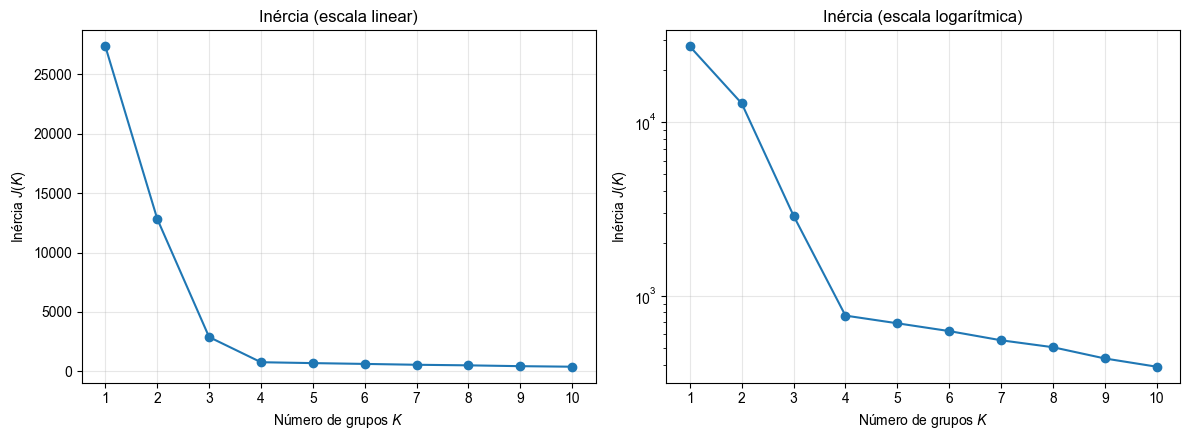

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

axs[0].plot(ks, inercias, marker="o")
axs[0].set_title("Inércia (escala linear)")

axs[1].plot(ks, inercias, marker="o")
axs[1].set_yscale("log")
axs[1].set_title("Inércia (escala logarítmica)")

for ax in axs:
    ax.set_xlabel("Número de grupos $K$")
    ax.set_ylabel("Inércia $J(K)$")
    ax.set_xticks(ks)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Observe que **o cotovelo não é óbvio na escala linear**: a curva já "dobra" em $K = 3$, porque a queda de $K = 2$ para $K = 3$ é muito maior que as seguintes. A tabela e a escala logarítmica mostram que a queda de $K = 3$ para $K = 4$ ainda é grande (cerca de 73%) e que, a partir de $K = 5$, as reduções ficam entre cerca de 9% e 14%: o cotovelo "verdadeiro" está em $K = 4$.

## 6. Limitações do $k$-means

No conjunto das "duas luas", os grupos naturais são curvos e entrelaçados. O $k$-means com $K = 2$ corta as luas ao meio.

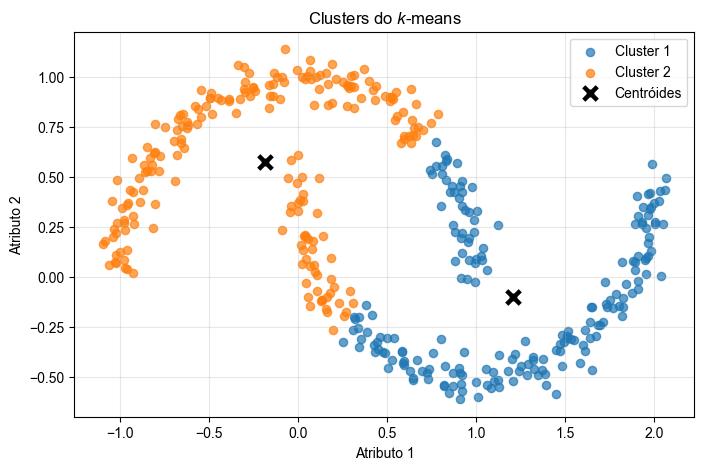

In [27]:
X3, y3 = make_moons(n_samples=400, noise=0.06, random_state=0)

modelo_km = KMeans(n_clusters=2, n_init=10, random_state=0)
rot_km = modelo_km.fit_predict(X3)          # rótulos (também em modelo_km.labels_)
centroides = modelo_km.cluster_centers_     # centróides, shape (2, 2)

for c in range(2):
    mask = rot_km == c
    plt.scatter(X3[mask, 0], X3[mask, 1], s=35, alpha=0.7, label=f"Cluster {c+1}")
plt.scatter(centroides[:, 0], centroides[:, 1],
            marker="X", s=220, c="black", edgecolors="white", linewidths=2,
            label="Centróides", zorder=5)
plt.title("Clusters do $k$-means")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()